# Entregável 1 — Relatório de Aquisição dos Biossinais

**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Ferreira Lessa & Matheus Rocha Gomes da Silva 
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.
Data: Março e Abril de 2026

---


## Objetivo

Este notebook descreve a etapa de **Aquisição dos Biossinais**, responsável por documentar as condições originais de aquisição do dataset PTB-XL, caracterizar a base de dados de forma demográfica e clínica, e realizar inspeções visuais do sinal bruto de ECG. São abordados:

1. Caracterização do biossinal e do hardware de aquisição
2. Justificativa da taxa de amostragem via Teorema de Nyquist
3. Protocolo experimental e ambiente de coleta
5. Visualização dos sinais brutos de ECG (12 derivações)
6. Identificação **visual** de possíveis problemas (saturação, drift de baseline e ruído de linha)

> **Nota metodológica:** O PTB-XL é um dataset público de referência internacional, com coleta realizada em ambiente hospitalar controlado, validado por especialistas cardiologistas. Os sinais brutos (.hea/.dat no formato WFDB) são carregados diretamente, sem nenhum pré-processamento, preservando as características originais de aquisição.

Aqui não fazemos nenhuma transformação nos sinais — a saída é um arquivo de metadados enriquecido (`ptbxl_metadata_enriched.csv`) que servirá de base para todos os notebooks subsequentes do pipeline.

In [15]:
# Descomente a linha abaixo para instalar as dependências, se necessário
# !pip install -r ../../../requirements.txt

## 1. Importações e Dependências
Bibliotecas necessárias:
- `pandas` e `numpy` para manipulação de dados,
- `matplotlib` e `seaborn` para visualizações,
- `wfdb` para leitura dos sinais no formato PhysioNet,
- `scipy` para análise espectral.

In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import scipy.signal as signal
from IPython.display import display, Markdown
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

---
## 2. Download e Verificação do Dataset PTB-XL

O dataset PTB-XL está disponível publicamente no PhysioNet:  
https://physionet.org/content/ptb-xl/1.0.3/

A célula abaixo verifica se o dataset já está presente localmente antes de tentar download.


In [17]:
DATA_DIR = Path('../../../data/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3')
print(f'   Dados em : {DATA_DIR.resolve()}')

if not DATA_DIR.exists():
    print('Dataset não encontrado. Iniciando download do PhysioNet (pode levar vários minutos).')
    wfdb.dl_database('ptb-xl/1.0.3', dl_dir=str(DATA_DIR))
    print('Download concluído!')
else:
    arquivos_hea = list(DATA_DIR.rglob('*.hea'))
    print(f'Dataset encontrado em: {DATA_DIR.resolve()}')
    print(f'Arquivos de cabeçalho (.hea) localizados: {len(arquivos_hea)}')


Dataset encontrado em: C:\Users\User\Desktop\Biossinais\data\ptb-xl\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3
Arquivos de cabeçalho (.hea) localizados: 43598


## 3. Configurações Globais
Definimos aqui as constantes do projeto. Optamos pela amostragem de **100 Hz** pois cobre a banda diagnóstica do ECG (0,05–40 Hz) com margem, respeitando ao critério de Nyquist (`fs ≥ 80 Hz`), e reduz o custo computacional em 5× comparado à de 500 Hz.Posteriormente essa justificativa de amostragem e explicação do Critério de Nyquist serão mais aprofundadadas na seção 1.3.


In [2]:
FS = 100
N_LEADS = 12
LEAD_NAMES = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
FOLDS_TREINO = [1, 2, 3, 4, 5, 6, 7, 8]
FOLD_VAL = 9
FOLD_TEST = 10

FIGS_DIR  = Path('../figuras')
OUT_DIR  = Path('../outputs')
for d in [FIGS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Configuração concluída.')
print(f'   Figuras em: {FIGS_DIR.resolve()}')
print(f'   Outputs em: {OUT_DIR.resolve()}')


## 3. Carregamento dos Metadados Base
O PTB-XL organiza seus metadados em dois arquivos CSV principais.
 - O `ptbxl_database.csv` contém informações de cada registro (idade, sexo, diagnósticos)
 - O `scp_statements.csv` traz o dicionário de códigos diagnósticos SCP-ECG.

In [3]:
print("Carregando ptbxl_database.csv...")
df = pd.read_csv(os.path.join(, 'ptbxl_database.csv'), index_col='ecg_id')

# Convertendo a coluna scp_codes de string para dicionário Python
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

print("Carregando scp_statements.csv...")
scp_statements = pd.read_csv(os.path.join(, 'scp_statements.csv'), index_col=0)

print(f"Dataset carregado: {df.shape[0]} registros e {df.shape[1]} colunas originais.")

Carregando ptbxl_database.csv...
Carregando scp_statements.csv...
Dataset carregado: 21799 registros e 27 colunas originais.


---
## Seção 1 — Contextualização do Dataset

### 1.1 O Sinal de ECG e sua Relevância Clínica
O biossinal utilizado é o **Eletrocardiograma (ECG)** de **12 derivações** no padrão clínico internacional, composto por:

| Grupo | Derivações | Região monitorada |
|-------|-----------|-------------------|
| Membros (bipolares) | I, II, III | Plano frontal |
| Membros (unipolares aumentadas) | aVR, aVL, aVF | Plano frontal |
| Precordiais | V1, V2, V3, V4, V5, V6 | Plano horizontal |

[Animação em Inglês explicando o ECG de 12 Derivações](https://www.alilamedicalmedia.com/pt/-/galleries/images-videos-by-medical-specialties/cardiology-and-vascular-diseases/-/medias/4d57ce72-0d39-4525-b523-329941b9edcf-ecg-de-12-derivacoes-explicado-animacao-em-ingles)

O ECG registra a atividade elétrica do coração ao longo do tempo através de eletrodos posicionados na superfície corporal. O padrão clínico utiliza 12 derivações que oferecem perspectivas complementares do mesmo fenômeno elétrico. É o padrão-ouro para diagnóstico de arritmias, isquemia miocárdica, hipertrofia e diversas outras condições cardíacas.

Cada derivação mostra a mesma sequência — despolarização atrial (onda P), despolarização ventricular (complexo QRS) e repolarização ventricular (onda T) — sob ângulos diferentes. Essa redundância é necessária: certos diagnósticos só aparecem em derivações específicas. Por exemplo, infarto anterior se manifesta em V1–V4; infarto inferior aparece em II, III e aVF.
[O que é complexo QRS?](https://www.linkedin.com/posts/carolnascimentto777_o-que-%C3%A9-complexo-qrs-o-complexo-qrs-%C3%A9-activity-7126330076274507776-JUxx?utm_source=social_share_send&utm_medium=member_desktop_web&rcm=ACoAAFZ5CzwB0me7CLrCu9z1MQS_sdETD5DMHxU)
---



In [4]:
# 1.2 Protocolo de Aquisição Original
n_registros = len(df)
n_pacientes = df['patient_id'].nunique()
n_devices = df['device'].nunique()
n_sites = df['site'].nunique()

display(Markdown(f"""
### 1.2 Protocolo de Aquisição Original

| Parâmetro | Valor |
|---|---|
| **Equipamento** | Dispositivos Schiller AG (fabricante suíço) |
| **Período de coleta** | Outubro de 1989 a Junho de 1996 |
| **Instituição** | Physikalisch-Technische Bundesanstalt (PTB), Berlim, Alemanha |
| **Registros** | {n_registros} registros de 10 segundos |
| **Pacientes** | {n_pacientes} pacientes distintos |
| **Dispositivos** | {n_devices} modelos diferentes em {n_sites} sites |
| **Derivações** | 12 padrão (I, II, III, aVL, aVR, aVF, V1–V6) |
| **Freq. original** | 400 Hz → reamostrado p/ 500 Hz (interpolação cúbica) |
| **Freq. downsampled** | 100 Hz (decimação do sinal de 500 Hz) |
| **Precisão** | 16 bits, resolução de 1 µV/LSB |
| **Formato** | WFDB (PhysioNet), arquivos `.dat` + `.hea` |
"""))


### 1.2 Protocolo de Aquisição Original

| Parâmetro | Valor |
|---|---|
| **Equipamento** | Dispositivos Schiller AG (fabricante suíço) |
| **Período de coleta** | Outubro de 1989 a Junho de 1996 |
| **Instituição** | Physikalisch-Technische Bundesanstalt (PTB), Berlim, Alemanha |
| **Registros** | 21799 registros de 10 segundos |
| **Pacientes** | 18869 pacientes distintos |
| **Dispositivos** | 11 modelos diferentes em 51 sites |
| **Derivações** | 12 padrão (I, II, III, aVL, aVR, aVF, V1–V6) |
| **Freq. original** | 400 Hz → reamostrado p/ 500 Hz (interpolação cúbica) |
| **Freq. downsampled** | 100 Hz (decimação do sinal de 500 Hz) |
| **Precisão** | 16 bits, resolução de 1 µV/LSB |
| **Formato** | WFDB (PhysioNet), arquivos `.dat` + `.hea` |


### 1.3 Justificativa do Critério de Nyquist
Pelo Teorema de Nyquist-Shannon, para reconstruir um sinal com componente máxima `f_max`, a taxa de amostragem precisa ser `fs ≥ 2 × f_max`. A banda de interesse diagnóstica do ECG vai de 0,05 Hz até cerca de 40 Hz, o que exige no mínimo 80 Hz. Portanto, a taxa de 100 Hz que adotamos satisfaz o critério com folga, e os 500 Hz só seriam necessários para análise de micro-potenciais tardios ou deep learning com resolução temporal fina.

In [5]:
# 1.4 Processo de Anotação dos Labels
pct_human = df['validated_by_human'].value_counts(normalize=True).get(True, 0) * 100
pct_auto = df['initial_autogenerated_report'].value_counts(normalize=True).get(True, 0) * 100

display(Markdown(f"""
### 1.4 Processo de Anotação dos Labels
O processo de rotulagem do PTB-XL seguiu múltiplas etapas: laudo inicial (por cardiologista ou gerado automaticamente), conversão para códigos SCP-ECG, revisão por segundo cardiologista, e anotação de qualidade do sinal.

- **{pct_human:.1f}%** dos registros possuem validação humana confirmada (`validated_by_human = True`).
- **{pct_auto:.1f}%** tiveram o laudo inicial gerado automaticamente pelo dispositivo ECG.
"""))

display(df['validated_by_human'].value_counts())
display(df['initial_autogenerated_report'].value_counts())


### 1.4 Processo de Anotação dos Labels
O processo de rotulagem do PTB-XL seguiu múltiplas etapas: laudo inicial (por cardiologista ou gerado automaticamente), conversão para códigos SCP-ECG, revisão por segundo cardiologista, e anotação de qualidade do sinal.

- **73.7%** dos registros possuem validação humana confirmada (`validated_by_human = True`).
- **31.3%** tiveram o laudo inicial gerado automaticamente pelo dispositivo ECG.


validated_by_human
True     16056
False     5743
Name: count, dtype: int64

initial_autogenerated_report
False    14986
True      6813
Name: count, dtype: int64

### 1.5 Verossimilhança dos Diagnósticos (Likelihood)
A coluna `scp_codes` armazena um dicionário onde cada chave é um código SCP e o valor é a verossimilhança (0–100%), que reflete o grau de certeza do cardiologista:

| Likelihood | Significado |
|---|---|
| 0% | Statement de forma/ritmo (binário) ou certeza mínima |
| 15% | "Não se pode excluir" |
| 50% | "Possivelmente", "talvez" |
| 80% | "Compatível com" |
| 100% | Diagnóstico confirmado |

Para classificação, adotaremos o limiar de **likelihood ≥ 50** para considerar um diagnóstico como positivo.

In [6]:
# 1.6 Estrutura do Arquivo de Metadados — visão geral das colunas
display(Markdown("### 1.6 Estrutura do Arquivo de Metadados"))
display(Markdown("**Amostra dos dados brutos:**"))
display(df[['patient_id', 'age', 'sex', 'height', 'weight', 'report', 'scp_codes', 'validated_by_human', 'strat_fold']].head(5))

# Completude dos campos
pct_h = df['height'].notna().mean() * 100
pct_w = df['weight'].notna().mean() * 100
pct_ax = df['heart_axis'].notna().mean() * 100

display(Markdown(f"""
**Completude dos campos opcionais:**
- Altura: {pct_h:.1f}% preenchidos
- Peso: {pct_w:.1f}% preenchidos
- Eixo cardíaco: {pct_ax:.1f}% preenchidos
"""))

### 1.6 Estrutura do Arquivo de Metadados

**Amostra dos dados brutos:**

,patient_id,age,sex,height,weight,report,scp_codes,validated_by_human,strat_fold
ecg_id,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,sinusrhythmus periphere niederspannung,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",True,3
2,13243.0,19.0,0,NaN,70.0,sinusbradykardie sonst normales ekg,"{'NORM': 80.0, 'SBRAD': 0.0}",True,2
3,20372.0,37.0,1,NaN,69.0,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",True,5
4,17014.0,24.0,0,NaN,82.0,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",True,3
5,17448.0,19.0,1,NaN,70.0,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",True,4



**Completude dos campos opcionais:**
- Altura: 32.0% preenchidos
- Peso: 43.2% preenchidos
- Eixo cardíaco: 61.2% preenchidos


---
## Seção 2 — Panorama Estatístico do Dataset

### 2.1 Distribuição Demográfica

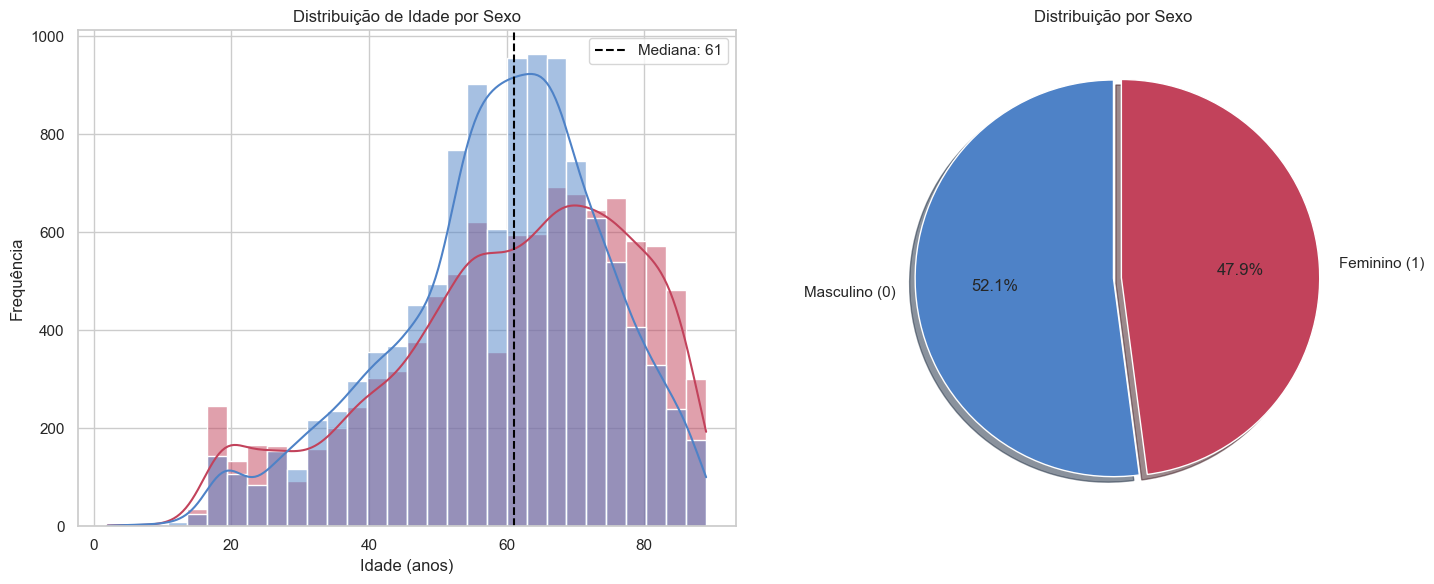

In [7]:
# Limpeza da idade (valores de 300 representam pacientes >= 90 anos, anonimizados)
df['age_clean'] = df['age'].replace(300, np.nan)

mediana_idade = df['age_clean'].median()
iqr_idade = df['age_clean'].quantile(0.75) - df['age_clean'].quantile(0.25)

# --- Plot 1: Idade por Sexo + Pizza ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=df, x='age_clean', hue='sex', bins=30,
             kde=True, ax=axes[0], alpha=0.5, palette=['#4e82c7', '#c2425b'])
axes[0].set_title('Distribuição de Idade por Sexo')
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(mediana_idade, color='black', linestyle='--', label=f'Mediana: {mediana_idade:.0f}')
axes[0].legend()

sex_pct = df['sex'].value_counts(normalize=True)
axes[1].pie(sex_pct, labels=['Masculino (0)', 'Feminino (1)'], autopct='%1.1f%%',
            colors=['#4e82c7', '#c2425b'], explode=(0, 0.04), shadow=True, startangle=90)
axes[1].set_title('Distribuição por Sexo')

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'distribuicao_demografica.png'), dpi=150, bbox_inches='tight')
plt.show()

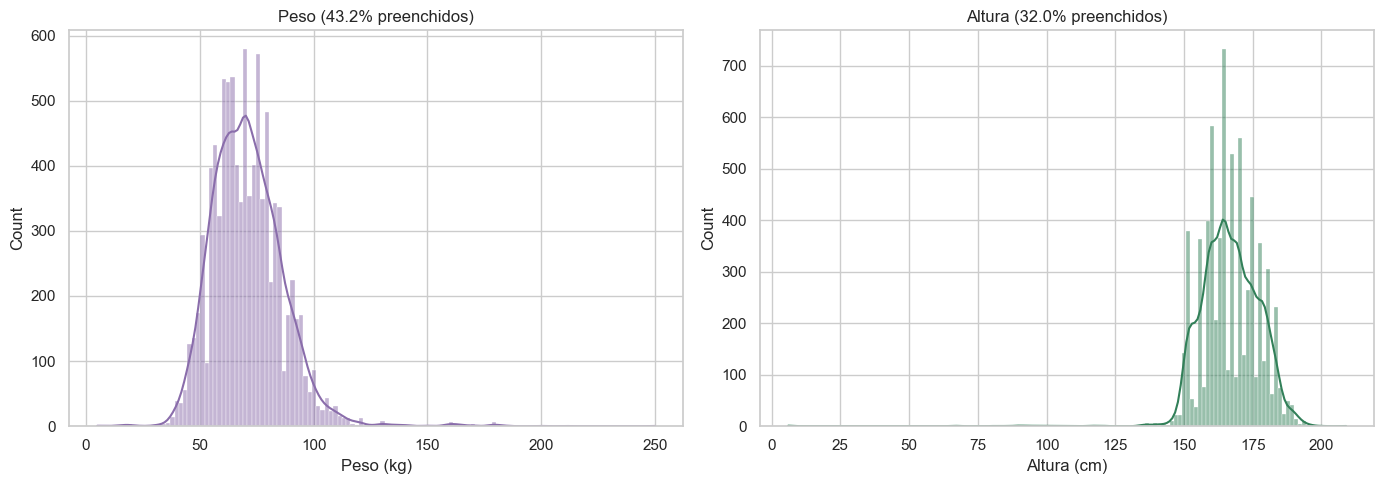

In [8]:
# --- Plot 2: Peso e Altura ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pct_w = df['weight'].notna().mean() * 100
pct_h = df['height'].notna().mean() * 100

sns.histplot(data=df, x='weight', kde=True, ax=axes[0], color='#8a6dab')
axes[0].set_title(f'Peso ({pct_w:.1f}% preenchidos)')
axes[0].set_xlabel('Peso (kg)')

sns.histplot(data=df, x='height', kde=True, ax=axes[1], color='#328059')
axes[1].set_title(f'Altura ({pct_h:.1f}% preenchidos)')
axes[1].set_xlabel('Altura (cm)')

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'peso_altura.png'), dpi=150, bbox_inches='tight')
plt.show()

C:\Users\josel\AppData\Local\Temp\ipykernel_18512\637258787.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_devices.index, y=df_devices.values, palette='crest')


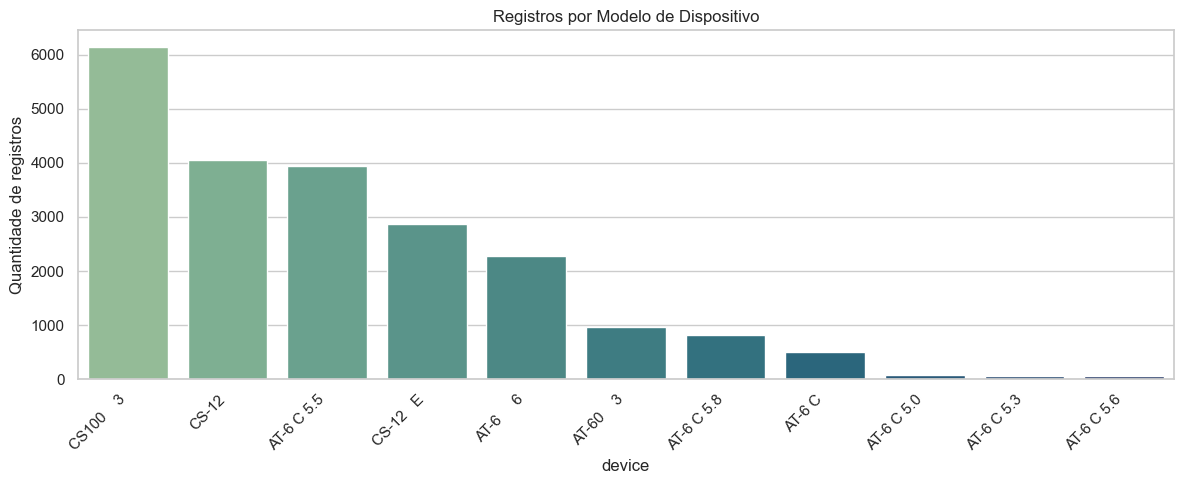

**(Espaço para comentário do aluno — dica: comente sobre o balanceamento demográfico do dataset, se a representação masculino/feminino é adequada, e se a distribuição de idade faz sentido para um dataset clínico cardíaco.)**

In [9]:
# --- Plot 3: Dispositivos ---
fig = plt.figure(figsize=(12, 5))
df_devices = df['device'].value_counts()
sns.barplot(x=df_devices.index, y=df_devices.values, palette='crest')
plt.title('Registros por Modelo de Dispositivo')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Quantidade de registros')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'dispositivos.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: comente sobre o balanceamento demográfico do dataset, se a representação masculino/feminino é adequada, e se a distribuição de idade faz sentido para um dataset clínico cardíaco.)**"))

### 2.2 Criação das Colunas de Superclasse Diagnóstica
O PTB-XL utiliza códigos SCP-ECG detalhados, mas para o nosso pipeline de classificação é mais prático agrupá-los em 5 superclasses diagnósticas: **NORM** (normal), **MI** (infarto do miocárdio), **CD** (distúrbio de condução), **STTC** (alterações ST/T) e **HYP** (hipertrofia). A informação de mapeamento vem do próprio `scp_statements.csv`.

In [10]:
df_diagnostic = scp_statements[scp_statements.diagnostic == 1]
scp_to_superclass = dict(zip(df_diagnostic.index, df_diagnostic.diagnostic_class))

def get_superclasses(scp_dict, threshold=50):
    """Retorna lista de superclasses cujos diagnósticos têm likelihood >= threshold."""
    superclasses = set()
    for scp, likelihood in scp_dict.items():
        if scp in scp_to_superclass and likelihood >= threshold:
            superclasses.add(scp_to_superclass[scp])
    return list(superclasses)

df['diagnostic_superclass'] = df['scp_codes'].apply(get_superclasses)
df['n_superclasses'] = df['diagnostic_superclass'].apply(len)

multi_label = df['n_superclasses'].value_counts().sort_index()
display(Markdown("**Distribuição multi-label** (quantidade de superclasses simultâneas por registro):"))
display(pd.DataFrame({'N Superclasses': multi_label.index, 'Registros': multi_label.values}))

display(Markdown("**(Espaço para comentário do aluno — dica: discuta o que significa ter registros com 0, 1, 2 ou mais superclasses. Registros com 0 superclasses geralmente possuem apenas statements de forma/ritmo.)**"))

**Distribuição multi-label** (quantidade de superclasses simultâneas por registro):

,N Superclasses,Registros
0,0,1426
1,1,15983
2,2,3484
3,3,776
4,4,130


**(Espaço para comentário do aluno — dica: discuta o que significa ter registros com 0, 1, 2 ou mais superclasses. Registros com 0 superclasses geralmente possuem apenas statements de forma/ritmo.)**

### 2.3 Distribuição de Labels Diagnósticos

C:\Users\josel\AppData\Local\Temp\ipykernel_18512\178191726.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_super.values, y=freq_super.index, palette='magma')


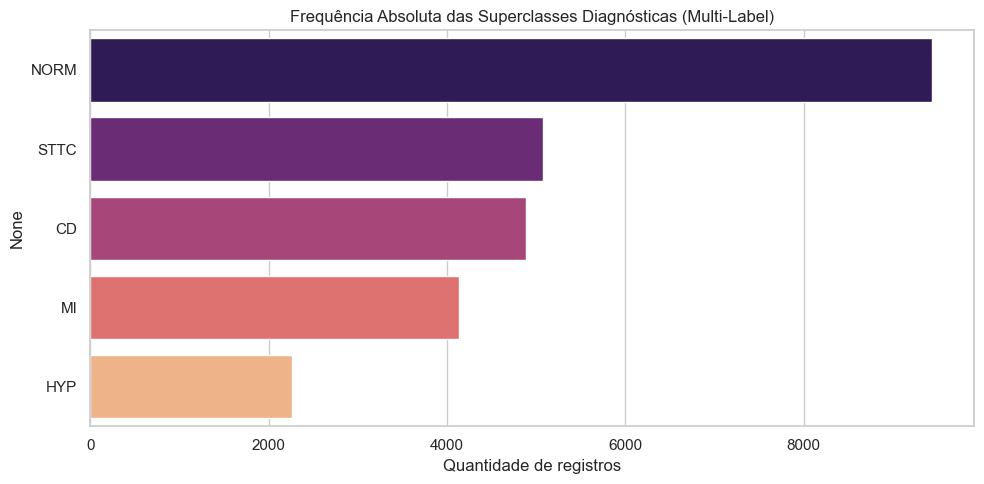

,Registros,% do total
NORM,9438,43.3
STTC,5078,23.3
CD,4891,22.4
MI,4134,19.0
HYP,2258,10.4


**(Espaço para comentário do aluno — dica: identifique qual é a classe dominante, se existe desbalanceamento entre classes, e o que isso pode implicar para o treinamento dos modelos.)**

In [11]:
all_superclasses = [cls for array in df['diagnostic_superclass'] for cls in array]
freq_super = pd.Series(all_superclasses).value_counts()

fig = plt.figure(figsize=(10, 5))
sns.barplot(x=freq_super.values, y=freq_super.index, palette='magma')
plt.title('Frequência Absoluta das Superclasses Diagnósticas (Multi-Label)')
plt.xlabel('Quantidade de registros')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'superclasses_frequencia.png'), dpi=150, bbox_inches='tight')
plt.show()

display(pd.DataFrame({'Registros': freq_super, '% do total': (freq_super / len(df) * 100).round(1)}))

display(Markdown("**(Espaço para comentário do aluno — dica: identifique qual é a classe dominante, se existe desbalanceamento entre classes, e o que isso pode implicar para o treinamento dos modelos.)**"))

### 2.4 Distribuição de Statements de Forma e Ritmo
Além dos diagnósticos, o PTB-XL rotula os registros com códigos de **ritmo** (e.g., ritmo sinusal, AFIB) e **forma** (e.g., QRS anormal). Esses não possuem graduação de likelihood — são presença/ausência.

C:\Users\josel\AppData\Local\Temp\ipykernel_18512\2613227177.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=all_rhythms.head(8).values, y=all_rhythms.head(8).index, palette='viridis', ax=axes[0])
C:\Users\josel\AppData\Local\Temp\ipykernel_18512\2613227177.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=all_forms.head(8).values, y=all_forms.head(8).index, palette='crest', ax=axes[1])


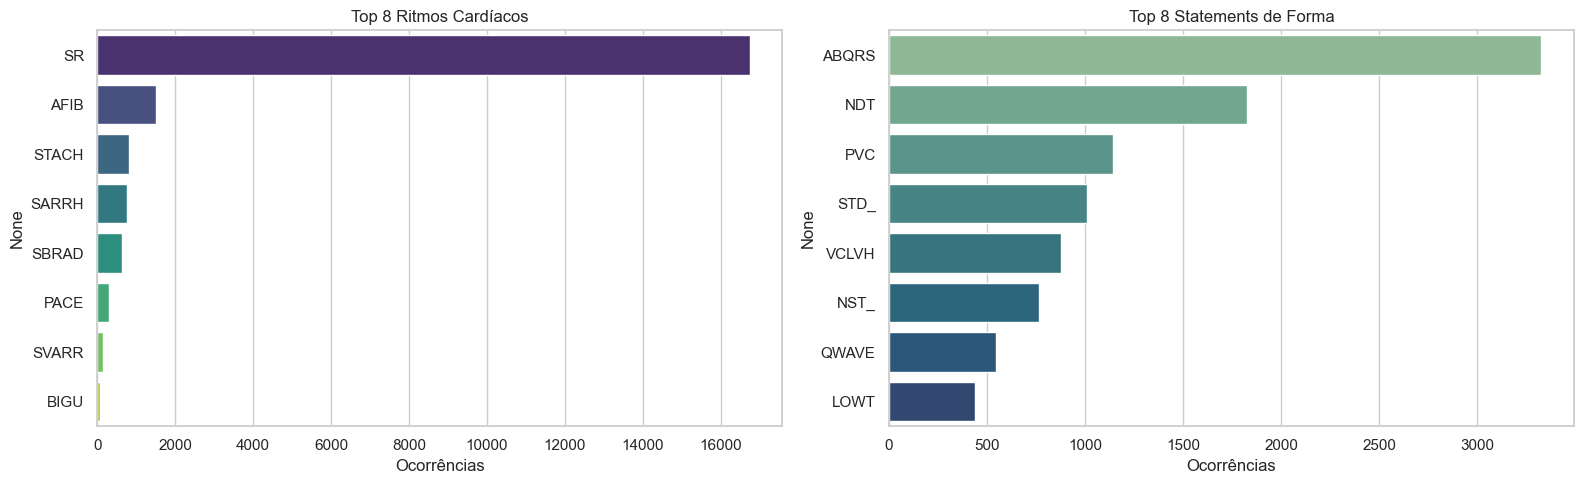

**(Espaço para comentário do aluno — dica: note que o ritmo sinusal normal (SR) domina amplamente. AFIB é a arritmia mais comum. Discuta a relevância clínica disso.)**

In [12]:
# Ritmos
df_rhythm = scp_statements[scp_statements.rhythm == 1]
def get_rhythms(scp_dict):
    return [scp for scp in scp_dict.keys() if scp in df_rhythm.index]

all_rhythms = pd.Series([r for subset in df['scp_codes'].apply(get_rhythms) for r in subset]).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=all_rhythms.head(8).values, y=all_rhythms.head(8).index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 8 Ritmos Cardíacos')
axes[0].set_xlabel('Ocorrências')

# Formas
df_form = scp_statements[scp_statements.form == 1]
def get_forms(scp_dict):
    return [scp for scp in scp_dict.keys() if scp in df_form.index]

all_forms = pd.Series([f for subset in df['scp_codes'].apply(get_forms) for f in subset]).value_counts()

sns.barplot(x=all_forms.head(8).values, y=all_forms.head(8).index, palette='crest', ax=axes[1])
axes[1].set_title('Top 8 Statements de Forma')
axes[1].set_xlabel('Ocorrências')

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'ritmo_forma.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: note que o ritmo sinusal normal (SR) domina amplamente. AFIB é a arritmia mais comum. Discuta a relevância clínica disso.)**"))

### 2.5 Multiplicidade de Registros por Paciente
Um paciente pode ter feito mais de um exame ao longo dos anos. É fundamental que todos os registros de um mesmo paciente estejam no mesmo fold do cross-validation para evitar data leakage.

In [13]:
records_per_patient = df.groupby('patient_id').size().value_counts().sort_index()
display(pd.DataFrame({'Registros por paciente': records_per_patient.index, 'Quantidade de pacientes': records_per_patient.values}))

# Verificação de integridade: todos os registros de um paciente estão no mesmo fold?
leakage_check = df.groupby('patient_id')['strat_fold'].nunique().max()
if leakage_check == 1:
    display(Markdown("✅ **Verificação anti-leakage aprovada:** todos os registros de um mesmo paciente estão contidos no mesmo fold. Sem risco de contaminação entre treino e teste."))
else:
    display(Markdown("⚠️ **Atenção:** encontrados pacientes em mais de um fold. Investigar!"))

,Registros por paciente,Quantidade de pacientes
0,1,16758
1,2,1590
2,3,350
3,4,99
4,5,43
5,6,16
6,7,5
7,8,4
8,9,3
9,10,1


✅ **Verificação anti-leakage aprovada:** todos os registros de um mesmo paciente estão contidos no mesmo fold. Sem risco de contaminação entre treino e teste.

---
## Seção 3 — Carregamento e Visualização do Sinal Bruto

### 3.1 Função de Carregamento com WFDB

In [14]:
def load_ecg(ecg_id, dataframe, path_base, fs=100):
    """Carrega o sinal de ECG usando a biblioteca wfdb."""
    linha = dataframe.loc[ecg_id]
    file_target = linha['filename_lr'] if fs == 100 else linha['filename_hr']
    signal_arr, fields = wfdb.rdsamp(os.path.join(path_base, file_target))
    return signal_arr, fields

In [15]:
# 3.2 Seleção de Registros Representativos
df['is_pure_norm'] = df['diagnostic_superclass'].apply(lambda x: x == ['NORM'])
df['has_quality_issues'] = df[['baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems']].notna().any(axis=1)

# Buscando exemplares variados por filtros programáticos
try:
    id_norm = df[(df['is_pure_norm']) & (df['validated_by_human'] == True) & (~df['has_quality_issues'])].index[0]
except IndexError:
    id_norm = df[df['is_pure_norm']].index[0]

try:
    id_mi = df[df['diagnostic_superclass'].apply(lambda x: 'MI' in x)].index[0]
except IndexError:
    id_mi = df.index[1]

try:
    id_afib = df[df['scp_codes'].apply(lambda d: 'AFIB' in d)].index[0]
except IndexError:
    id_afib = df.index[2]

try:
    id_baseline = df[df['baseline_drift'].notna()].index[0]
except IndexError:
    id_baseline = df.index[3]

registros_selecionados = {
    'NORM (sinal limpo)': id_norm,
    'MI (infarto)': id_mi,
    'AFIB (fibrilação atrial)': id_afib,
    'Baseline drift': id_baseline
}

display(Markdown("**Registros selecionados para visualização:**"))
for desc, eid in registros_selecionados.items():
    display(Markdown(f"- **{desc}**: ECG ID {eid} | Superclasse: {df.loc[eid, 'diagnostic_superclass']}"))

**Registros selecionados para visualização:**

- **NORM (sinal limpo)**: ECG ID 2 | Superclasse: ['NORM']

- **MI (infarto)**: ECG ID 77 | Superclasse: ['CD', 'MI']

- **AFIB (fibrilação atrial)**: ECG ID 17 | Superclasse: []

- **Baseline drift**: ECG ID 4 | Superclasse: ['NORM']

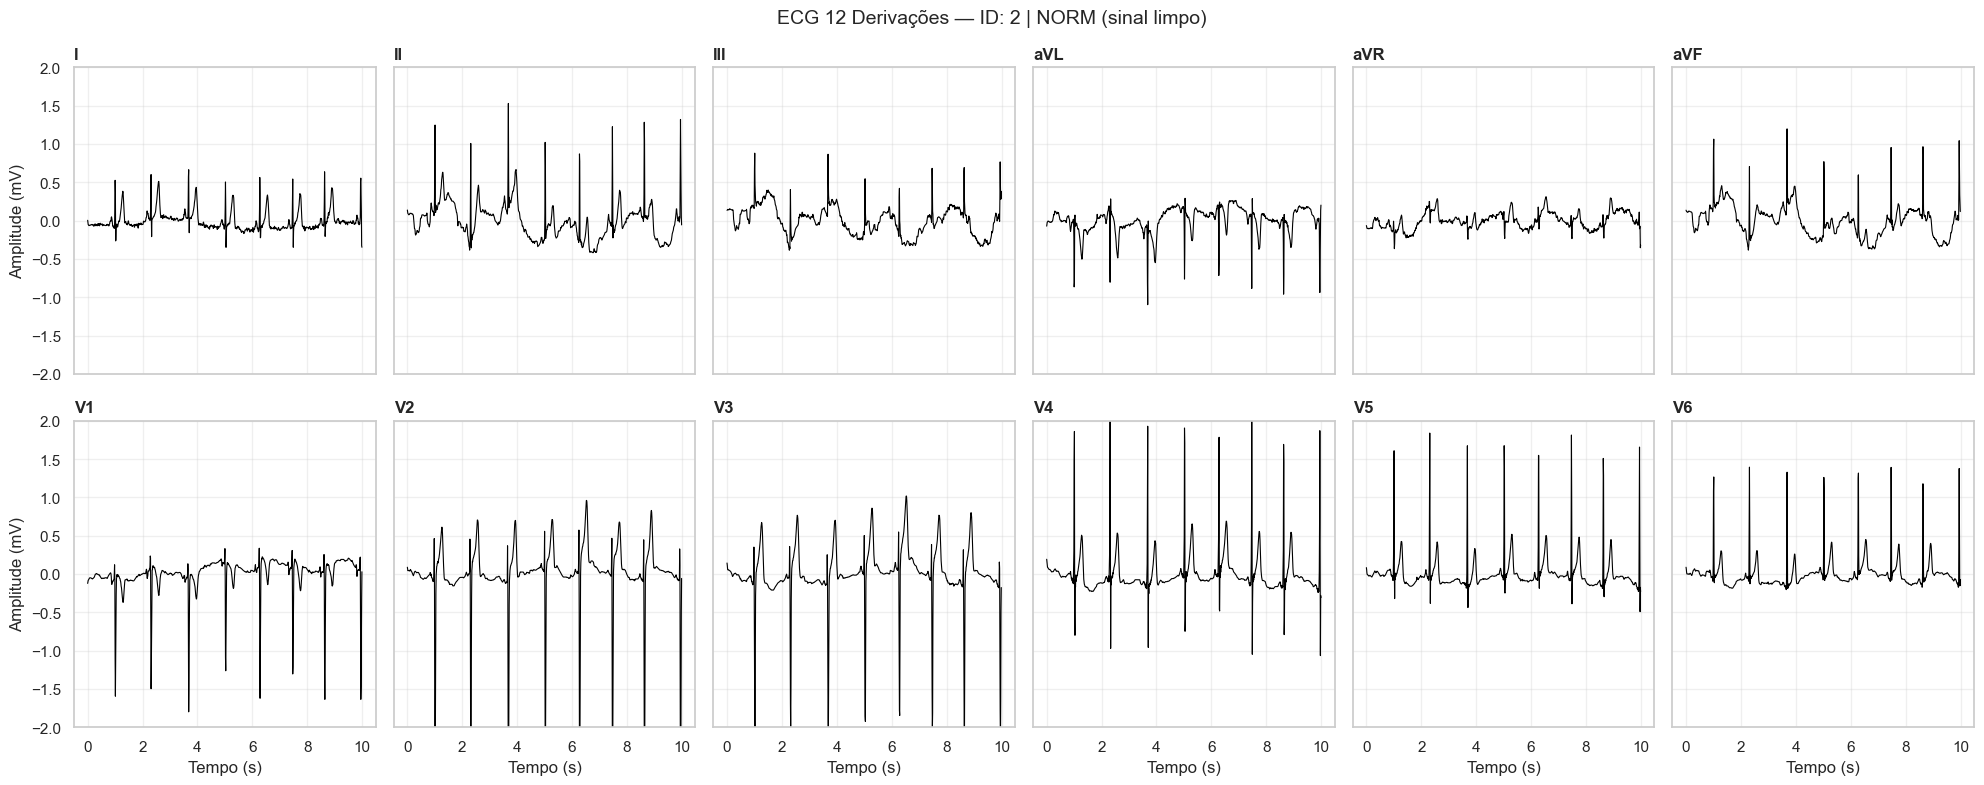

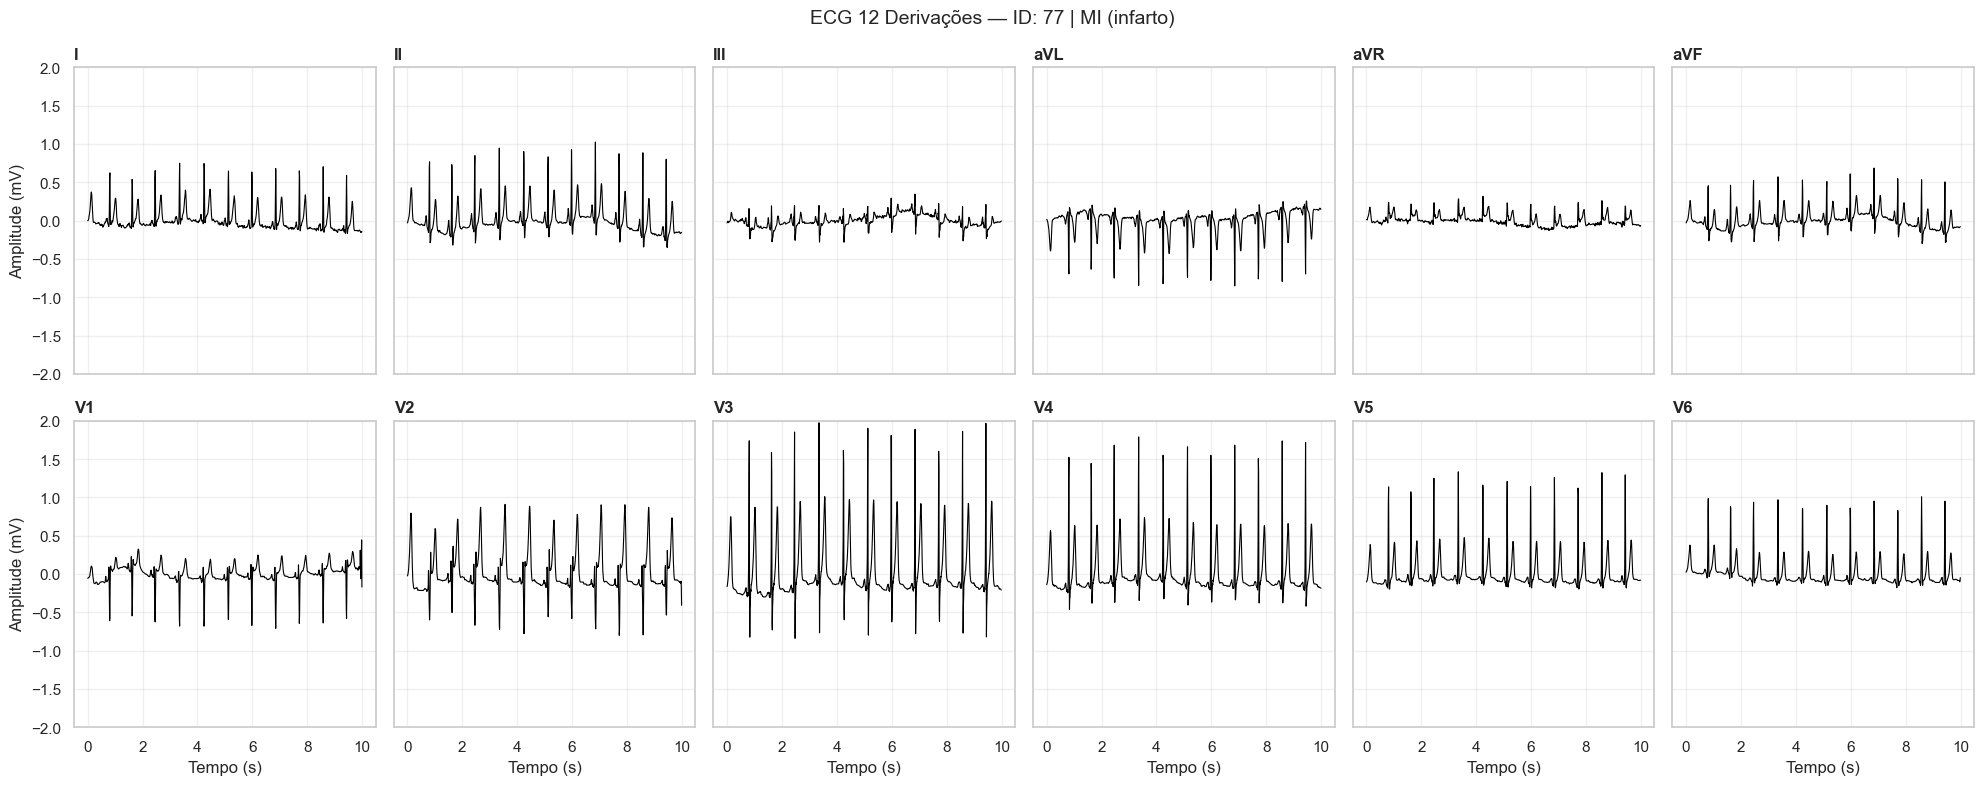

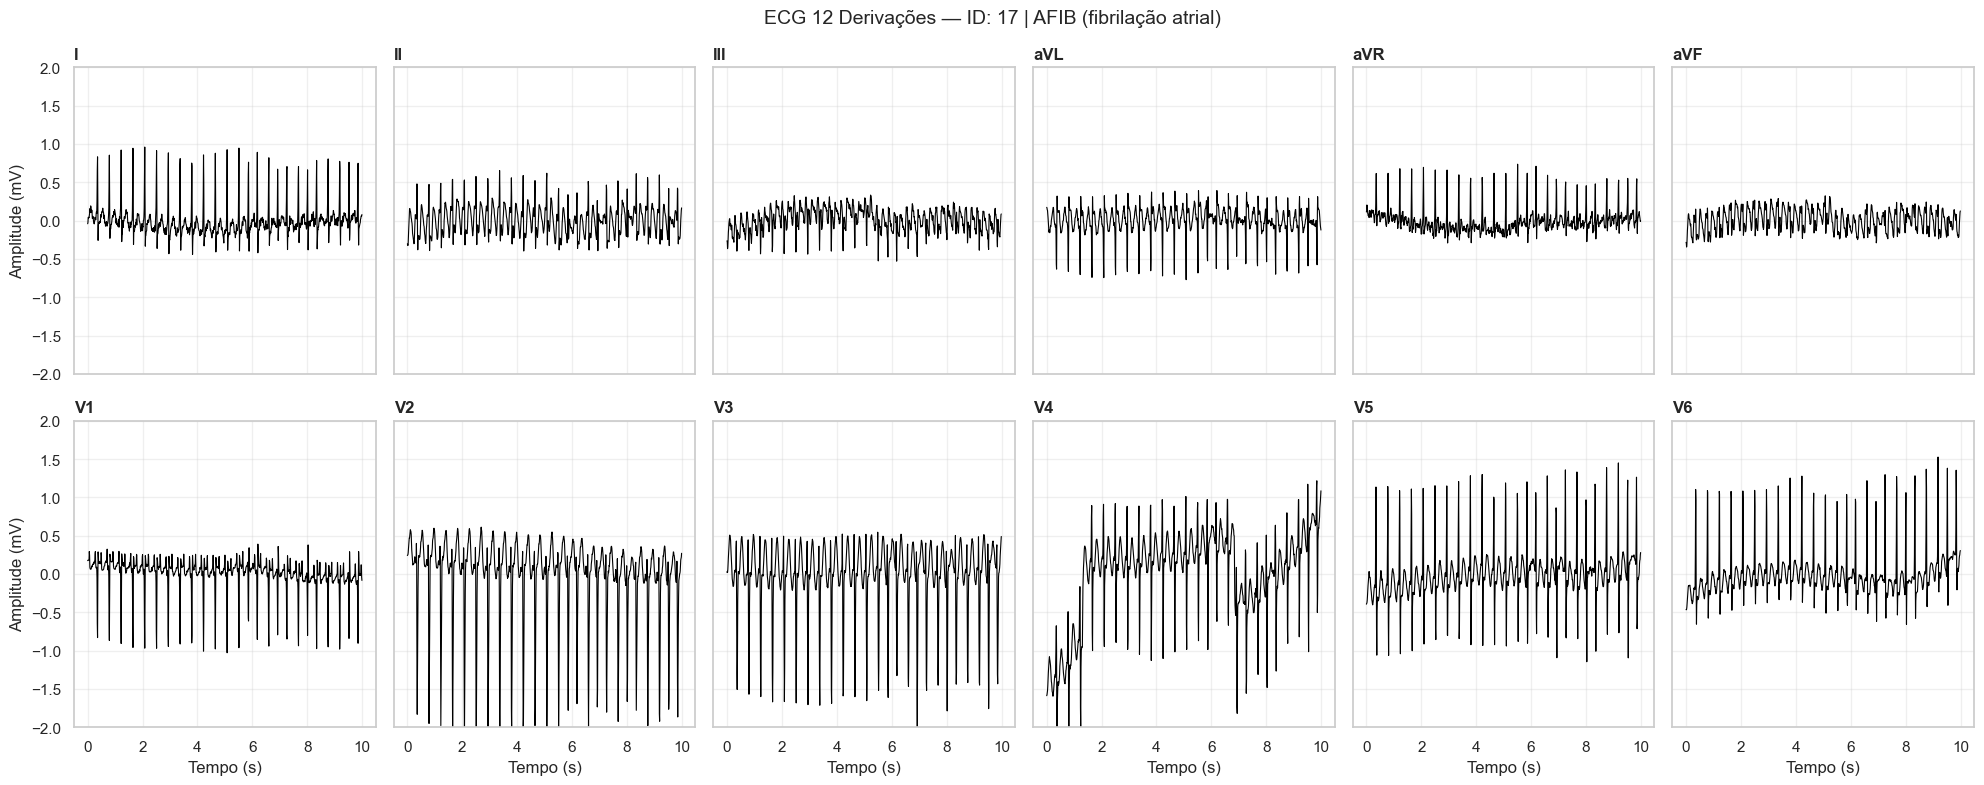

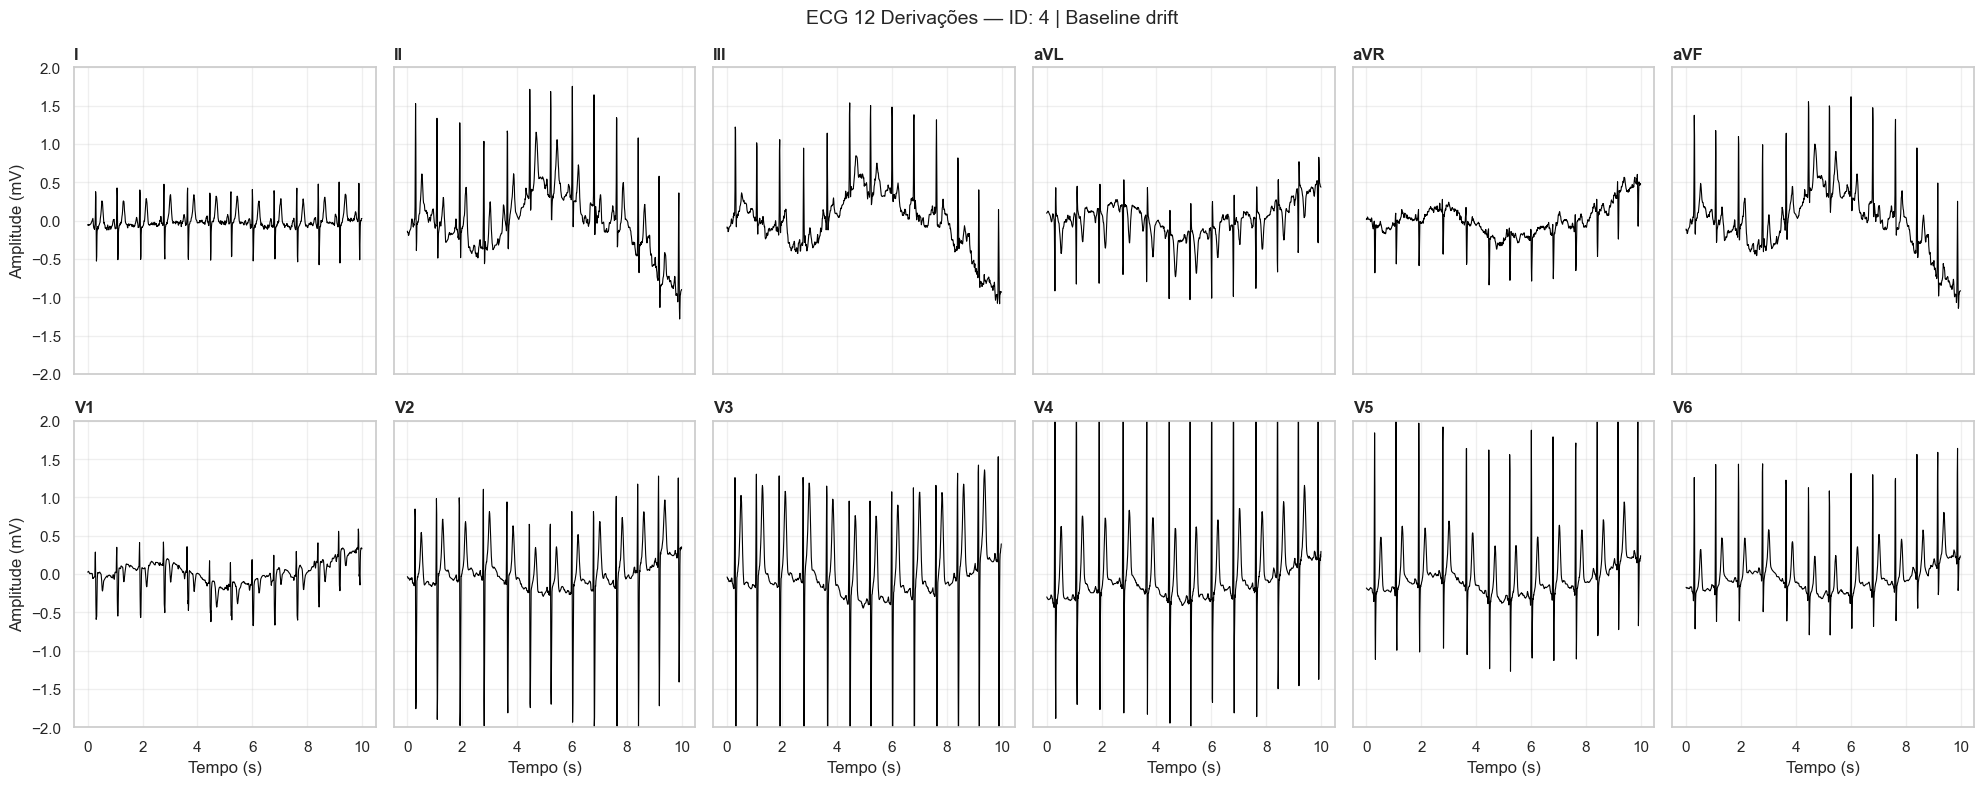

**(Espaço para comentário do aluno — dica: compare visualmente as morfologias. No registro NORM, espere ondas P, QRS e T bem definidas. No MI, procure por alterações de ST. No AFIB, note a ausência de onda P. No baseline drift, observe a oscilação lenta do eixo.)**

In [16]:
# 3.3 Visualização das 12 Derivações
def plot_clinical_ecg(ecg_id, titulo_extra=""):
    sig, header = load_ecg(ecg_id, df, , FS)
    t = np.arange(sig.shape[0]) / FS

    fig, axes = plt.subplots(2, 6, figsize=(20, 8), sharex=True, sharey=True)
    fig.suptitle(f'ECG 12 Derivações — ID: {ecg_id} | {titulo_extra}', fontsize=14)

    for i in range(12):
        row, col = i // 6, i % 6
        ax = axes[row, col]
        ax.plot(t, sig[:, i], color='black', linewidth=0.8)
        ax.set_title(LEAD_NAMES[i], loc='left', fontweight='bold')
        ax.set_ylim(-2, 2)
        ax.grid(alpha=0.3)
        if row == 1:
            ax.set_xlabel('Tempo (s)')
        if col == 0:
            ax.set_ylabel('Amplitude (mV)')

    plt.tight_layout()
    fig.savefig(os.path.join(FIGS_DIR, f'ecg_12leads_{ecg_id}.png'), dpi=150, bbox_inches='tight')
    plt.show()

for desc, eid in registros_selecionados.items():
    plot_clinical_ecg(eid, titulo_extra=desc)

display(Markdown("**(Espaço para comentário do aluno — dica: compare visualmente as morfologias. No registro NORM, espere ondas P, QRS e T bem definidas. No MI, procure por alterações de ST. No AFIB, note a ausência de onda P. No baseline drift, observe a oscilação lenta do eixo.)**"))

### 3.4 Análise Espectral Visual do Sinal Bruto (Derivação DII)
Usando o método de Welch, visualizamos a distribuição de energia no espectro de frequências. Isso nos dá uma visão do "antes" que será comparada com o "depois" da filtragem no Entregável 4.

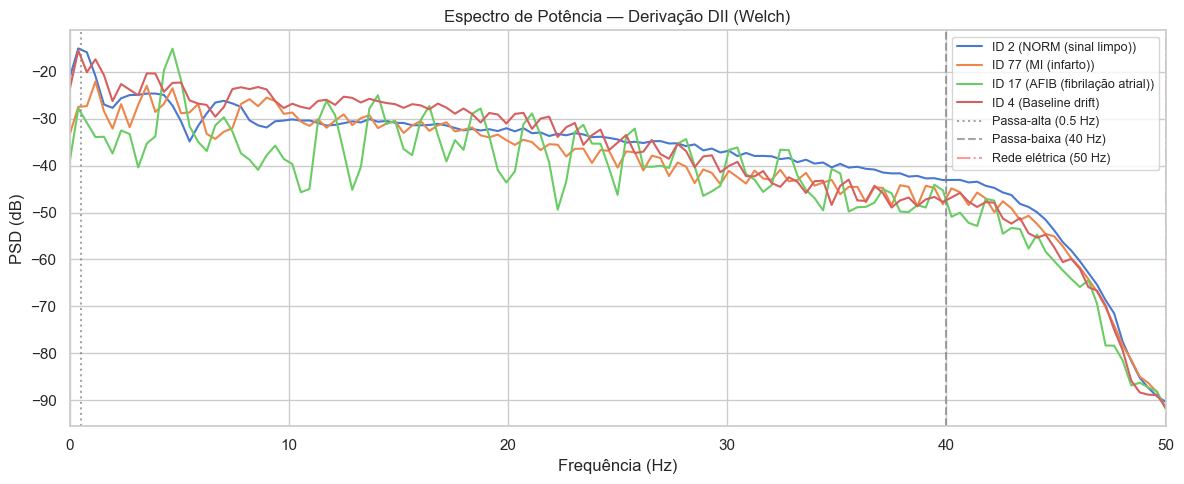

**(Espaço para comentário do aluno — dica: observe como a energia se concentra abaixo de 30 Hz para a maioria dos registros. Verifique se algum registro apresenta pico próximo de 50 Hz, indicando interferência de rede.)**

In [17]:
fig = plt.figure(figsize=(12, 5))

for desc, eid in registros_selecionados.items():
    sig, _ = load_ecg(eid, df, , FS)
    dii = sig[:, 1]
    freqs, psd = signal.welch(dii, fs=FS, nperseg=256)
    psd_db = 10 * np.log10(psd + 1e-10)
    plt.plot(freqs, psd_db, label=f'ID {eid} ({desc})')

plt.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Passa-alta (0.5 Hz)')
plt.axvline(40, color='gray', linestyle='--', alpha=0.7, label='Passa-baixa (40 Hz)')
plt.axvline(50, color='red', linestyle='-.', alpha=0.4, label='Rede elétrica (50 Hz)')

plt.xlim(0, 50)
plt.xlabel('Frequência (Hz)')
plt.ylabel('PSD (dB)')
plt.title('Espectro de Potência — Derivação DII (Welch)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'espectro_welch_bruto.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: observe como a energia se concentra abaixo de 30 Hz para a maioria dos registros. Verifique se algum registro apresenta pico próximo de 50 Hz, indicando interferência de rede.)**"))

---
## Seção 4 — Enriquecimento do Metadado e Salvamento

### 4.1 Adição de Colunas Calculadas

In [18]:
def get_split(fold):
    if fold in FOLDS_TREINO:
        return 'train'
    elif fold == FOLD_VAL:
        return 'val'
    elif fold == FOLD_TEST:
        return 'test'
    return 'unknown'

df['split'] = df['strat_fold'].apply(get_split)

# Limpando colunas auxiliares
df.drop(columns=['age_clean'], inplace=True, errors='ignore')

In [19]:
# 4.2 Salvamento
caminho_resultado = '../outputs/ptbxl_metadata_enriched.csv'
df.to_csv(caminho_resultado)

n_train = len(df[df.split == 'train'])
n_val = len(df[df.split == 'val'])
n_test = len(df[df.split == 'test'])
n_problemas = df.has_quality_issues.sum()

display(Markdown(f"""
**Arquivo salvo em:** `{caminho_resultado}`

| Split | Registros |
|---|---|
| Treino (folds 1–8) | {n_train} |
| Validação (fold 9) | {n_val} |
| Teste (fold 10) | {n_test} |

Registros com problemas de qualidade anotados: **{n_problemas}**
"""))


**Arquivo salvo em:** `../outputs/ptbxl_metadata_enriched.csv`

| Split | Registros |
|---|---|
| Treino (folds 1–8) | 17418 |
| Validação (fold 9) | 2183 |
| Teste (fold 10) | 2198 |

Registros com problemas de qualidade anotados: **5010**


---
## Seção 5 — Síntese e Conexão

Neste primeiro entregável, o dataset PTB-XL foi carregado, inspecionado e documentado. Realizamos a caracterização demográfica e clínica, criamos o mapeamento para superclasses diagnósticas, verificamos a integridade dos folds contra data leakage, e visualizamos o sinal bruto em múltiplos cenários clínicos.

Os metadados foram enriquecidos com as colunas calculadas e salvos em `ptbxl_metadata_enriched.csv`. O próximo passo (Entregável 2) irá quantificar objetivamente a qualidade dos sinais usando métricas como SNR, kurtosis e entropia espectral.

**(Espaço para comentário do aluno — dica: faça um resumo pessoal das descobertas mais relevantes deste entregável: distribuição demográfica, presença de multi-label, qualidade geral do dataset.)**
